In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('OBSvsSIM_Values.csv')
# Drop rows where ALL values are NaN
df = df.dropna(how='all')

# print(df)
df.head()

,Position,SIM_WC_S,OBS_WC_S,SIM_WC_NS,OBS_WC_NS,Layer
0,3,0.1661,0.0022,0.0742,0.0025,4_(TOP)
1,9,0.1949,0.0031,0.0950,0.0103,3
2,15,0.2514,0.0048,0.1634,0.0888,2
3,21,0.4087,0.2670,0.4230,0.3093,1_(BOT)


### Plot the Theta vs Depth

In [5]:
POS = df['Position']
SIM_WC_NS = df['SIM_WC_NS']
OBS_WC_NS = df['OBS_WC_NS']
SIM_WC_S = df['SIM_WC_S']
OBS_WC_S = df['OBS_WC_S']

print("Water Content Fit Quality\n")
print(f"{'RMSE Range':<15}| {'Interpretation'}")
print("-" * 40)
print(f"< 0.02         | Very good fit")
print(f"0.02 – 0.05    | Reasonable fit")
print(f"> 0.05         | Weak fit")


Water Content Fit Quality

RMSE Range     | Interpretation
----------------------------------------
< 0.02         | Very good fit
0.02 – 0.05    | Reasonable fit
> 0.05         | Weak fit


In [13]:
RMSE_NS2 = np.sqrt((np.sum((OBS_WC_NS - SIM_WC_NS)**2))/4)
errors_NS = OBS_WC_NS - SIM_WC_NS

RMSE_NS = np.sqrt((np.mean((OBS_WC_NS - SIM_WC_NS)**2)))
n = len(errors_NS)

for i, e in enumerate(errors_NS):
    layer = n - i  # counts down from 4 to 1
    print(f"Layer {layer} error = {e:.5f}")

print("RMSE for the Non-Separated layers is", round(RMSE_NS, 5))
print("RMSE for the Non-Separated layers is", round(RMSE_NS2, 5))

if RMSE_NS < 0.02:
    print("It's a very good fit")
elif 0.02 <= RMSE_NS <= 0.05:
    print("It's a reasonable fit")
else:
    print("It's a weak fit")

Layer 4 error = -0.07170
Layer 3 error = -0.08470
Layer 2 error = -0.07460
Layer 1 error = -0.11370
RMSE for the Non-Separated layers is 0.08776
RMSE for the Non-Separated layers is 0.08776
It's a weak fit


In [19]:
RMSE_S = np.sqrt((np.mean((OBS_WC_S - SIM_WC_S)**2)))
RMSE_S2 = np.sqrt(((np.sum((OBS_WC_S - SIM_WC_S)**2)))/4)

errors_S = OBS_WC_S - SIM_WC_S

RMSE_Ex = (np.sum((OBS_WC_S - SIM_WC_S)**2))
final = np.sqrt(RMSE_Ex/4)
n = len(errors_S)

for i, e in enumerate(errors_S):
    layer = n - i  # counts down from 4 to 1
    print(f"Layer {layer} error = {e:.5f}")

print("RMSE for the Separated layers is", round(RMSE_S, 5))
# print("RMSE for the Separated layers is", round(RMSE_Ex, 5))
# print(final)
if RMSE_S < 0.02:
    print("It's a very good fit")
elif 0.02 <= RMSE_S <= 0.05:
    print("It's a reasonable fit")
else:
    print("It's a weak fit")

Layer 4 error = -0.16390
Layer 3 error = -0.19180
Layer 2 error = -0.24660
Layer 1 error = -0.14170
RMSE for the Separated layers is 0.19009
It's a weak fit


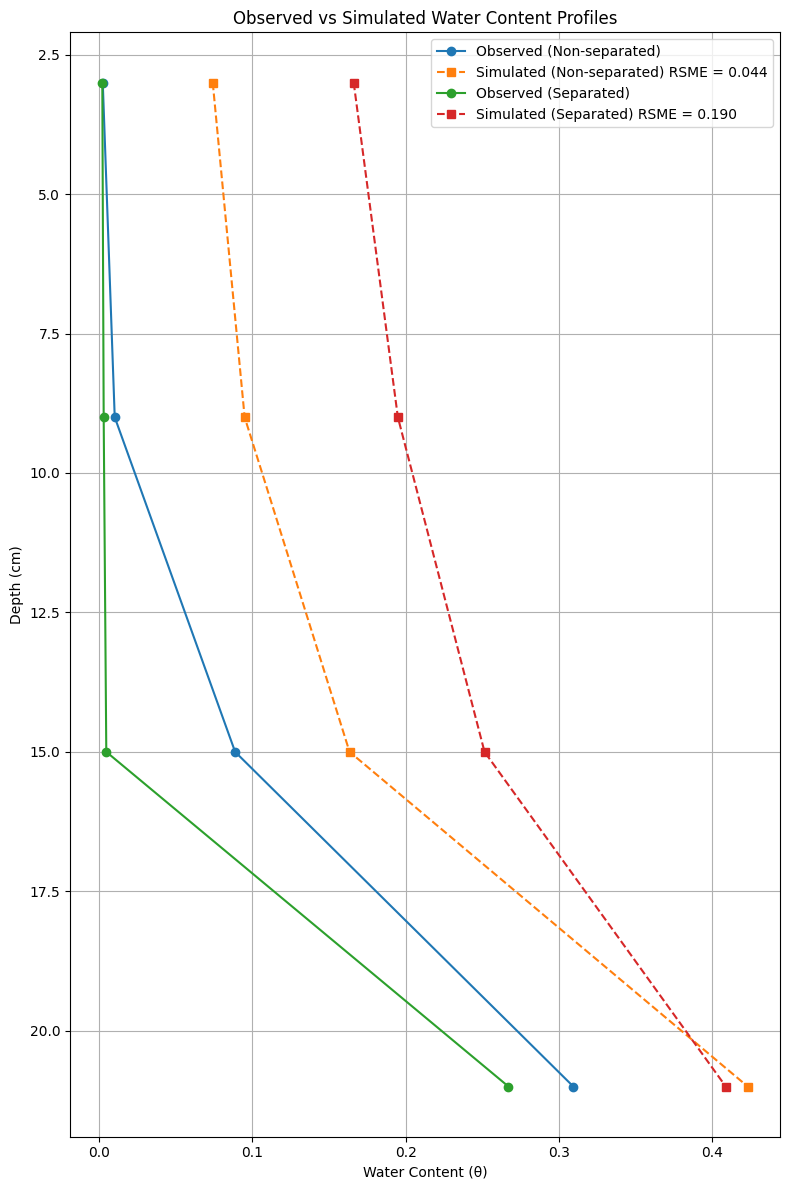

In [7]:

# plt.plot(SIM_WC_NS,POS)
# plt.plot(OBS_WC_NS,POS)

# Create figure
plt.figure(figsize=(8, 12))

# --- Non-separated ---
plt.plot(OBS_WC_NS, POS, 'o-', label='Observed (Non-separated)')
plt.plot(SIM_WC_NS, POS, 's--', label=f'Simulated (Non-separated) RSME = {RMSE_NS:.3f}')

# --- Separated ---
plt.plot(OBS_WC_S, POS, 'o-', label='Observed (Separated)')
plt.plot(SIM_WC_S, POS, 's--', label=f'Simulated (Separated) RSME = {RMSE_S:.3f}')

# Formatting
plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel('Water Content (θ)')
plt.ylabel('Depth (cm)')
plt.title('Observed vs Simulated Water Content Profiles')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

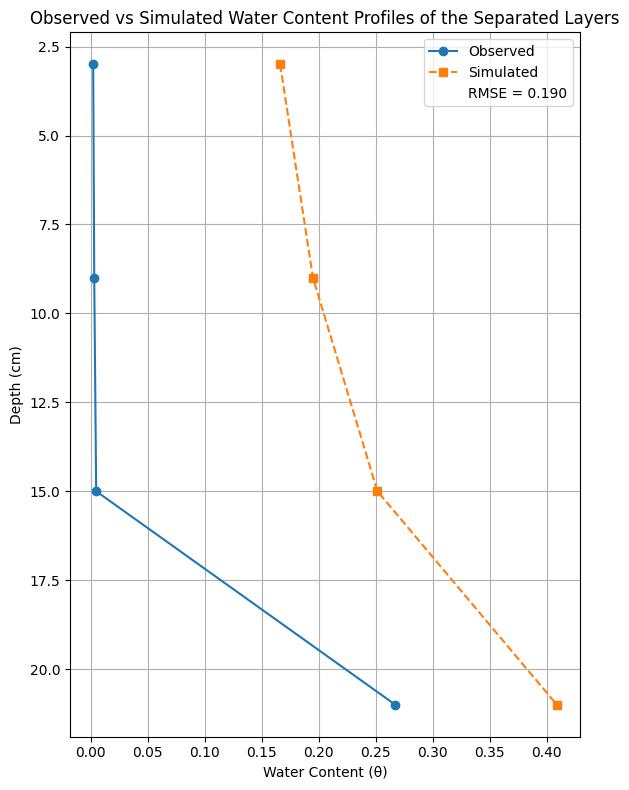

In [8]:
plt.figure(figsize=(6, 8))

# --- Separated ---
plt.plot(OBS_WC_S, POS, 'o-', label='Observed')
plt.plot(SIM_WC_S, POS, 's--', label='Simulated')

# --- Add RMSE as legend-only entry ---
plt.plot([], [], ' ', label=f'RMSE = {RMSE_S:.3f}')

plt.gca().invert_yaxis()
plt.xlabel('Water Content (θ)')
plt.ylabel('Depth (cm)')
plt.title('Observed vs Simulated Water Content Profiles of the Separated Layers')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

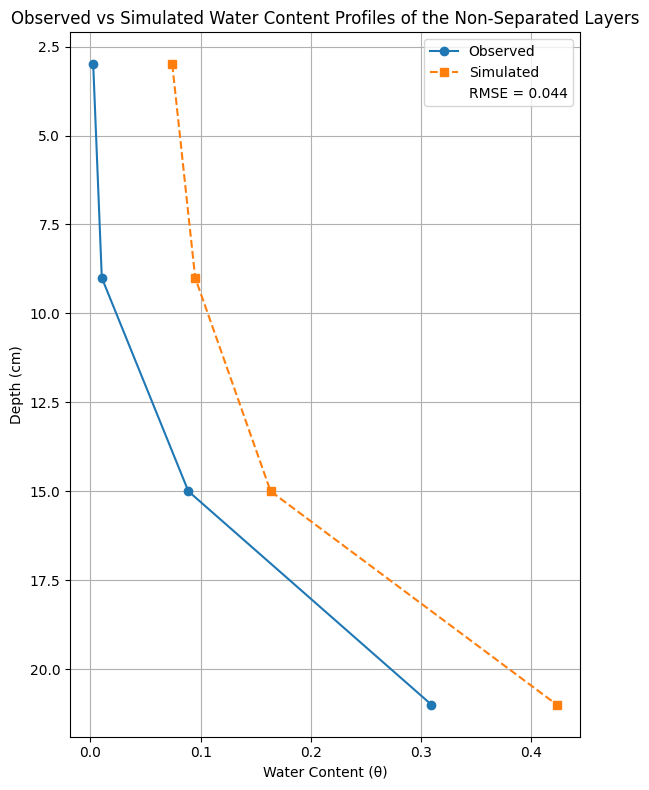

In [9]:
plt.figure(figsize=(6, 8))

# --- Non-separated ---
plt.plot(OBS_WC_NS, POS, 'o-', label='Observed')
plt.plot(SIM_WC_NS, POS, 's--', label='Simulated')

plt.plot([], [], ' ', label=f'RMSE = {RMSE_NS:.3f}')

plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel('Water Content (θ)')
plt.ylabel('Depth (cm)')
plt.title('Observed vs Simulated Water Content Profiles of the Non-Separated Layers')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Water Retention Curve (θ v ψ)

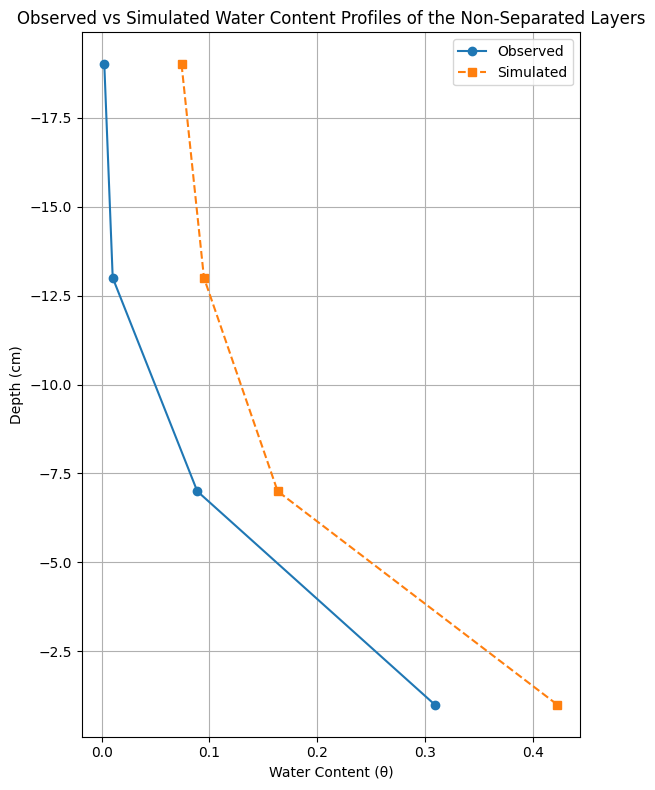

In [10]:
y = [-19,-13,-7,-1]


plt.figure(figsize=(6, 8))

# --- Non-separated ---
plt.plot(OBS_WC_NS, y, 'o-', label='Observed')
plt.plot(SIM_WC_NS, y, 's--', label='Simulated')

# plt.plot([], [], ' ', label=f'RMSE = {RMSE_NS:.3f}')

plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel('Water Content (θ)')
plt.ylabel('Depth (cm)')
plt.title('Observed vs Simulated Water Content Profiles of the Non-Separated Layers')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
